# Emotion Classification using a Transformer Encoder Built from Scratch



In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow.keras.layers import Embedding,Dense,LayerNormalization,Layer,Dropout,Input,Flatten,GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from datasets import load_dataset
from keras.optimizers import Adam


from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


## Project Goal

The goal of this project is to understand the components of a Transformer Encoder, including:

- Multi-Head Self Attention
- Positional Embeddings
- Feed Forward Networks
- Residual Connections
- Layer Normalization

The model is trained on the Emotion Dataset.


In [36]:
emotion = load_dataset("dair-ai/emotion")

X_train_raw = emotion["train"]["text"]
y_train = np.array(emotion["train"]["label"])

X_test_raw = emotion["validation"]["text"]
y_test = np.array(emotion["validation"]["label"])

max_features = 5000
maxlen = 100
tokenizer = Tokenizer(num_words=max_features, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)


X_train = tokenizer.texts_to_sequences(X_train_raw)
X_test = tokenizer.texts_to_sequences(X_test_raw)

X_train = pad_sequences(X_train, maxlen=maxlen, padding="post")
X_test = pad_sequences(X_test, maxlen=maxlen, padding="post")


## Multi-Head Self Attention

The attention mechanism allows each token to attend to all other tokens in the sequence.

For each token:

- Query vectors are generated.
- Key vectors are generated.
- Value vectors are generated.

Attention scores are computed using scaled dot-product attention.

In [ ]:
class MultiHeadAttintion(Layer):
  def __init__(self,embd_size,num_heads=8):
    super(MultiHeadAttintion,self).__init__()
    self.embd_size=embd_size
    self.num_heads=num_heads
    self.head_size=embd_size//num_heads
    self.query_dense=Dense(embd_size)
    self.key_dense=Dense(embd_size)
    self.value_dense=Dense(embd_size)
    self.combine_heads=Dense(embd_size)


  def attention(self,query,key,value):
    qk=tf.matmul(query,key,transpose_b=True)
    key_dim=tf.cast(tf.shape(key)[-1],tf.float32)
    scaled_score=qk/tf.sqrt(key_dim)
    scaled_score=tf.nn.softmax(scaled_score,axis=-1)
    return tf.matmul(scaled_score,value)


  def split_heads(self,x,batch_size):
    x=tf.reshape(x,(batch_size,-1,self.num_heads,self.head_size))
    return tf.transpose(x,perm=[0,2,1,3])


  def call(self,inputs):
    batch_size=tf.shape(inputs)[0]
    q=self.query_dense(inputs)
    k=self.key_dense(inputs)
    v=self.value_dense(inputs)
    q=self.split_heads(q,batch_size)
    k=self.split_heads(k,batch_size)
    v=self.split_heads(v,batch_size)
    att=self.attention(q,k,v)
    att=tf.transpose(att,perm=[0,2,1,3])
    att=tf.reshape(att,(batch_size,-1,self.embd_size))
    return self.combine_heads(att)

class TransformerBlock(Layer):
  def __init__(self,embd_size,num_heads,ffn,rate=0.1):
    super(TransformerBlock,self).__init__()
    self.att=MultiHeadAttintion(embd_size,num_heads)
    self.ffn=Sequential([
        Dense(ffn,activation="gelu"),
        Dense(embd_size)]
        )
    self.layerNormalization1=LayerNormalization(epsilon=1e-6)
    self.layerNormalization2=LayerNormalization(epsilon=1e-6)
    self.dropout1=Dropout(rate)
    self.dropout2=Dropout(rate)

  def call(self,inputs,training=False):
    att=self.att(inputs)
    att=self.dropout1(att,training=training)
    out1=self.layerNormalization1(inputs+att)
    ffn_out=self.ffn(out1)
    ffn_out=self.dropout2(ffn_out,training=training)
    return self.layerNormalization2(out1+ffn_out)

class Encoder(Layer):
  def __init__(self,num_layers,embd_size,num_heads,ffn):
      super(Encoder,self).__init__()
      self.num_layers=num_layers
      self.transformer=[TransformerBlock(embd_size,num_heads,ffn) for i in range(num_layers)]
  def call(self,inputs,training=True):
      x=inputs
      for i in range(self.num_layers):
        x=self.transformer[i](x,training=training)
      return x
y_train.shape


(16000,)

In [ ]:
class TP_Embedding(Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TP_Embedding,self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, inputs):
        maxlen = tf.shape(inputs)[1]
        positions = tf.range(0,limit=maxlen)
        positions = self.pos_emb(positions)
        inputs = self.token_emb(inputs)
        return inputs + positions

In [8]:
embed_dim=128
num_heads=8
num_layers=4
ff_dim=256
cats=int(y_train.max()+1)
cats


6

## Transformer Architecture
1- Token Embedding

2- Positional Embedding

3- Transformer Encoder layer

4- GlobalAvragePooling1D

5-Dense layer

6-Dense Classifcation Head

In [9]:
model =Sequential([
    TP_Embedding(maxlen,max_features,embed_dim),
    Encoder(num_layers, embed_dim, num_heads, ff_dim,),
    GlobalAveragePooling1D(),
    Dense(128,activation='gelu'),
    Dropout(0.3),
   Dense(cats,activation='softmax')
])




In [11]:
adam = Adam(learning_rate=3e-4)


ES=EarlyStopping(
     monitor='val_accuracy',
     patience=5,
     restore_best_weights=True
)


MCP=ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True

)

model.compile(
    optimizer=adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)


In [16]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tp__embedding (TP_Embedding)    │ (32, 100, 128)         │       652,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Encoder)               │ (32, 100, 128)         │       529,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (32, 128)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (32, 128)              │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (32, 6)                │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,600,020 (13.73 MB)

 Trainable params: 1,200,006 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,400,014 (9.16 MB)

In [12]:
history=model.fit(X_train,y_train,epochs=20,validation_data=[X_test,y_test],callbacks=[ES,MCP])

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - accuracy: 0.4294 - loss: 1.4097 - val_accuracy: 0.8365 - val_loss: 0.5016
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8854 - loss: 0.3332 - val_accuracy: 0.9055 - val_loss: 0.2616
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9176 - loss: 0.2058 - val_accuracy: 0.9070 - val_loss: 0.2403
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9308 - loss: 0.1705 - val_accuracy: 0.9025 - val_loss: 0.2627
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9407 - loss: 0.1455 - val_accuracy: 0.9055 - val_loss: 0.2692
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9507 - loss: 0.1190 - val_accuracy: 0.8945 - val_loss: 0.3152
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9566 - loss: 0.1078 - val_accuracy: 0.8935 - val_loss: 0.3294
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9669 - loss: 0.0857 - val_acc

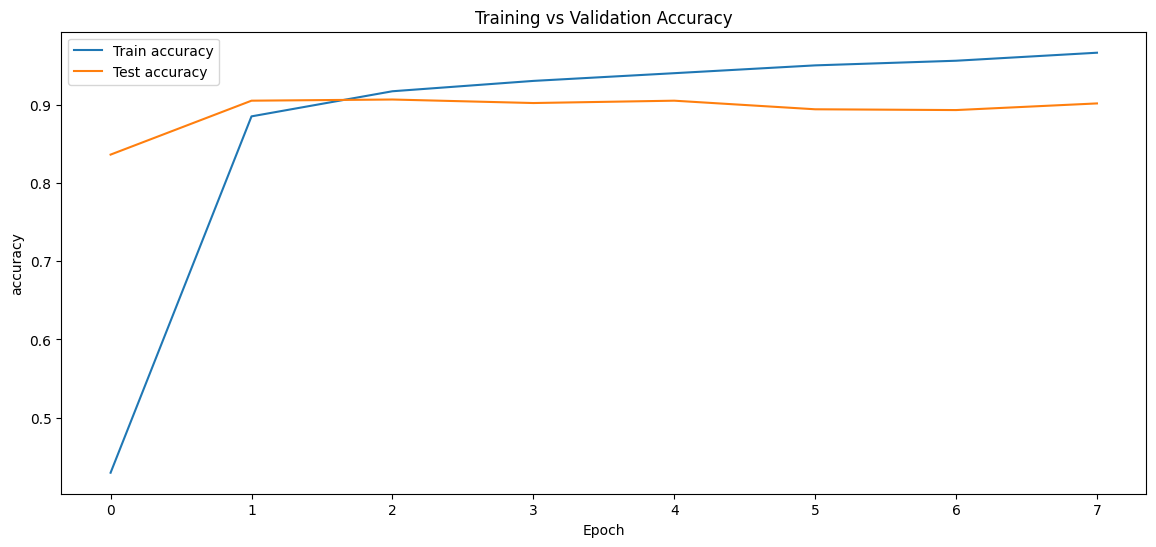

In [13]:
plt.figure(figsize=(14,6))
plt.plot(history.history["accuracy"],label=["Train accuracy"])
plt.plot(history.history["val_accuracy"],label=["Test accuracy"])
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

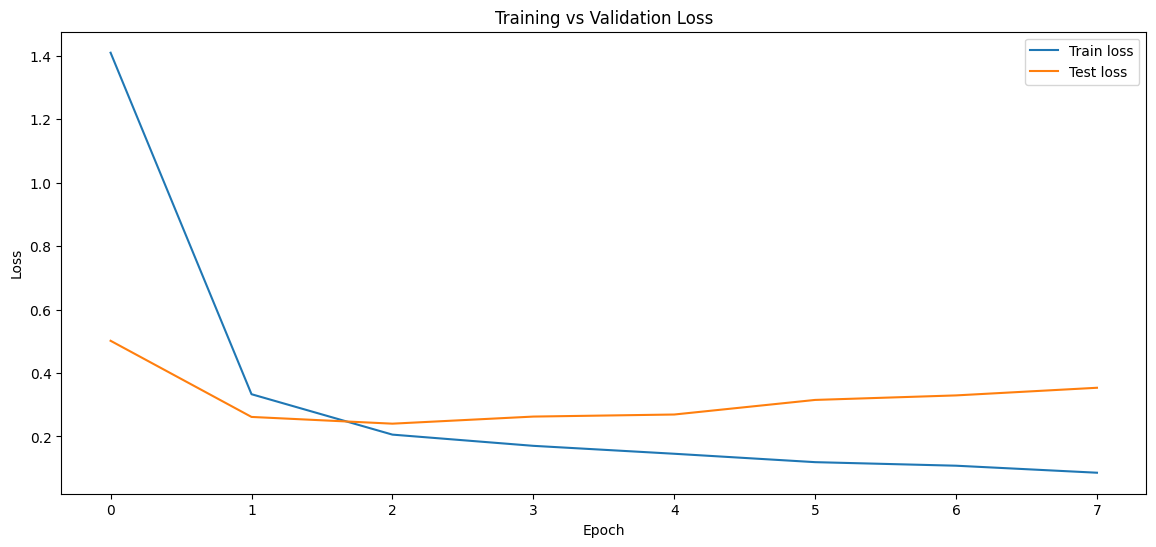

In [15]:
plt.figure(figsize=(14,6))
plt.plot(history.history["loss"],label=["Train loss"])
plt.plot(history.history["val_loss"],label=["Test loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

In [34]:
labels =emotion["train"].features["label"].names

y_pred=model.predict(X_test)
pred_classes=np.argmax(y_pred,axis=1)
cr=classification_report(y_test,pred_classes,target_names=labels)
print(cr)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

     sadness       0.95      0.91      0.93       550
         joy       0.93      0.94      0.93       704
        love       0.88      0.82      0.85       178
       anger       0.95      0.88      0.92       275
        fear       0.84      0.84      0.84       212
    surprise       0.67      0.99      0.80        81

    accuracy                           0.91      2000
   macro avg       0.87      0.90      0.88      2000
weighted avg       0.91      0.91      0.91      2000



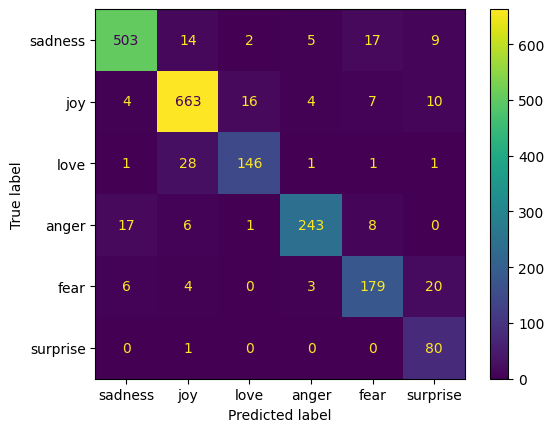

In [41]:
cm=confusion_matrix(y_test,pred_classes)
cmd=ConfusionMatrixDisplay(cm,display_labels=labels)
cmd.plot()

## Conclusion

This project contain a complete Transformer Encoder from scratch for NLP Multi classification tasks.

Future improvements may include:
- Larger Transformer Architectures
- Attention Visualization